# Part 1 — Anatomy of a Too-Good-To-Be-True Result

### Data leakage in wavelet-hybrid financial forecasting, and what an honest baseline looks like

**Ahmet Kaçmaz**

---

A very common recipe in the applied forecasting literature goes like this:

> Take a financial series → fit a linear model (ARIMA/ARFIMA) → decompose the residuals with a
> wavelet transform → train one LSTM per wavelet component → combine the LSTM outputs with a
> tree ensemble.

I built exactly that model for S&P 500 daily log returns and it reported an
**out-of-sample $R^2$ of 0.82 and 95% directional accuracy.**

That number is not just good. It is *impossible*. Daily index returns are, to a first
approximation, unpredictable — the entire asset-pricing literature reports out-of-sample $R^2$
between $-0.05$ and $+0.02$ for this task. An honest $R^2$ of 0.82 would mean the market is
broken.

So this notebook does three things:

1. **Reproduce** the pipeline and its 0.82 $R^2$, faithfully.
2. **Dissect** it. I find the leak, and then prove it is the *only* thing producing the number —
   by feeding the model pure random noise instead of its LSTM outputs and getting the same $R^2$ back.
3. **Rebuild** it correctly, with a strictly causal pipeline, and report the honest result.

The honest result is $R^2 \approx 0$. That is the correct answer, and Part 2 shows where the
same architecture *does* find real signal.

In [1]:
import os
import warnings

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping

SEED = 0
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

I0000 00:00:1783975990.679793  772170 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1783975992.416729  772170 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 0. Data

S&P 500 (`^GSPC`) daily OHLC, 2010-01-04 → 2023-12-29, cached to CSV so this notebook is
reproducible and does not depend on the `yfinance` API (whose column format has changed in
recent versions, silently breaking notebooks that index `df['Close']`).

In [2]:
df = pd.read_csv("../data/gspc.csv", index_col="Date", parse_dates=True)
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
df = df.dropna()

TEST_FRAC = 0.2
split = int(len(df) * (1 - TEST_FRAC))
train_df, test_df = df.iloc[:split], df.iloc[split:]

# pandas returns a read-only view under copy-on-write; pywt needs a writable buffer
r = np.array(df["log_return"].to_numpy(), dtype=float)
r_train, r_test = r[:split].copy(), r[split:].copy()

print(f"total days : {len(df)}   {df.index[0].date()} → {df.index[-1].date()}")
print(f"train      : {len(train_df):>4}   {train_df.index[0].date()} → {train_df.index[-1].date()}")
print(f"test       : {len(test_df):>4}   {test_df.index[0].date()} → {test_df.index[-1].date()}")
print(f"\ndaily return: mean={r.mean():.5f}  std={r.std():.5f}")

total days : 3521   2010-01-05 → 2023-12-29
train      : 2816   2010-01-05 → 2021-03-12
test       :  705   2021-03-15 → 2023-12-29

daily return: mean=0.00041  std=0.01107


---
# 1. The naive pipeline

This is a faithful reimplementation of the standard recipe. Read `predict()` carefully — the bug
is in plain sight, and it is the kind of bug that hides behind a class boundary.

In [3]:
class NaiveHybridModel:
    """ARIMA → wavelet(residuals) → LSTM-per-component → RandomForest combiner.

    Faithful to the standard recipe found throughout the applied literature.
    """

    def __init__(self, seq_length=10):
        self.seq_length = seq_length
        self.arfima_model = None
        self.lstm_model = None
        self.detail_models = []
        self.rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=SEED)

    def decompose(self, data):
        coeffs = pywt.wavedec(np.array(data, dtype=float), "db4", level=4)
        return coeffs[0], coeffs[1:]           # approximation, details

    def prepare_sequences(self, data):
        d = pd.DataFrame(np.asarray(data).reshape(-1, 1), columns=["returns"])
        d["volatility"] = d["returns"].rolling(10).std()
        d["momentum"] = d["returns"].rolling(5).mean()
        for i in range(1, 4):
            d[f"lag_{i}"] = d["returns"].shift(i)
        d = d.bfill().ffill()
        return np.array([d.iloc[i:i + self.seq_length].values
                         for i in range(len(d) - self.seq_length)])

    def create_lstm(self, shape):
        m = Sequential([
            Input(shape),
            LSTM(32, return_sequences=True), BatchNormalization(), Dropout(0.3),
            LSTM(16), BatchNormalization(), Dropout(0.3),
            Dense(32, activation="relu"), BatchNormalization(),
            Dense(16, activation="gelu"), BatchNormalization(),
            Dense(1),
        ])
        m.compile(optimizer="adam", loss="mse")
        return m

    def combine_predictions(self, approx_pred, detail_preds, y_true):
        n = min(len(approx_pred), len(y_true), min(len(d) for d in detail_preds))
        X = np.column_stack([approx_pred[:n]] + [d[:n] for d in detail_preds])
        self.rf_model.fit(X, y_true[:n])          # <<<<<<  fit
        return self.rf_model.predict(X)           # <<<<<<  predict on the same rows

    def fit(self, data):
        self.arfima_model = ARIMA(np.asarray(data), order=(2, 0, 0)).fit()
        residuals = np.asarray(data) - self.arfima_model.fittedvalues

        approx, details = self.decompose(residuals)
        X_approx = self.prepare_sequences(approx)
        X_details = [self.prepare_sequences(d) for d in details]
        y = residuals[self.seq_length:]

        n = min(len(X_approx), len(X_details[0]))
        X_approx, X_details, y = X_approx[:n], [d[:n] for d in X_details], y[:n]

        n_tr = int(n * 0.7)
        cb = [EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)]

        self.lstm_model = self.create_lstm(X_approx.shape[1:])
        self.lstm_model.fit(X_approx[:n_tr], y[:n_tr], epochs=150, batch_size=32,
                            validation_data=(X_approx[n_tr:], y[n_tr:]),
                            callbacks=cb, verbose=0)

        self.detail_models = []
        for Xd in X_details:
            m = self.create_lstm(Xd.shape[1:])
            m.fit(Xd[:n_tr], y[:n_tr], epochs=150, batch_size=32,
                  validation_data=(Xd[n_tr:], y[n_tr:]), callbacks=cb, verbose=0)
            self.detail_models.append(m)

        self._n_lstm_train = n_tr
        self._n_usable = n
        return self

    def predict(self, data):
        data = np.asarray(data)
        arfima_pred = self.arfima_model.forecast(len(data))
        residuals = data - arfima_pred

        approx, details = self.decompose(residuals)
        X_approx = self.prepare_sequences(approx)
        X_details = [self.prepare_sequences(d) for d in details]

        n = min(len(X_approx), min(len(d) for d in X_details))
        X_approx, X_details = X_approx[:n], [d[:n] for d in X_details]

        approx_pred = self.lstm_model.predict(X_approx, verbose=0)
        detail_preds = [m.predict(Xd, verbose=0)
                        for m, Xd in zip(self.detail_models, X_details)]

        # the combiner is handed the TEST residuals as `y_true`
        final = self.combine_predictions(
            approx_pred, detail_preds,
            residuals[self.seq_length:n + self.seq_length],
        )

        s = self.seq_length
        e = min(len(arfima_pred), s + len(final))
        return arfima_pred[s:e] + final[:e - s]


def evaluate(y_true, y_pred, label=""):
    out = {
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        # the definition this literature commonly uses: sign of the CHANGE in the return (see §3.3)
        "DirAcc": np.mean(np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred))),
        # the definition that answers "does the market go up tomorrow?"
        "DirAcc_sign": np.mean(np.sign(y_true) == np.sign(y_pred)),
    }
    if label:
        print(f"{label}\n" + "-" * len(label))
        for k, v in out.items():
            print(f"  {k:<12}: {v: .5f}")
    return out

In [4]:
naive = NaiveHybridModel(seq_length=10).fit(r_train)
naive_pred = naive.predict(r_test)

n_pred = len(naive_pred)
naive_true = r_test[naive.seq_length:naive.seq_length + n_pred]

naive_metrics = evaluate(naive_true, naive_pred, "NAIVE HYBRID PIPELINE — reported performance")
print(f"\n  Directional accuracy: "
      f"{int(np.sum(np.sign(np.diff(naive_true)) == np.sign(np.diff(naive_pred))))}"
      f"/{n_pred - 1}")

NAIVE HYBRID PIPELINE — reported performance
--------------------------------------------
  MSE         :  0.00001
  RMSE        :  0.00285
  MAE         :  0.00242
  R2          :  0.86924
  DirAcc      :  0.94872
  DirAcc_sign :  0.85000

  Directional accuracy: 37/39


**$R^2 = 0.82$ on daily S&P 500 log returns.**

If this were real it would be one of the most valuable results in quantitative finance. It is not
real. The rest of this notebook establishes exactly why.

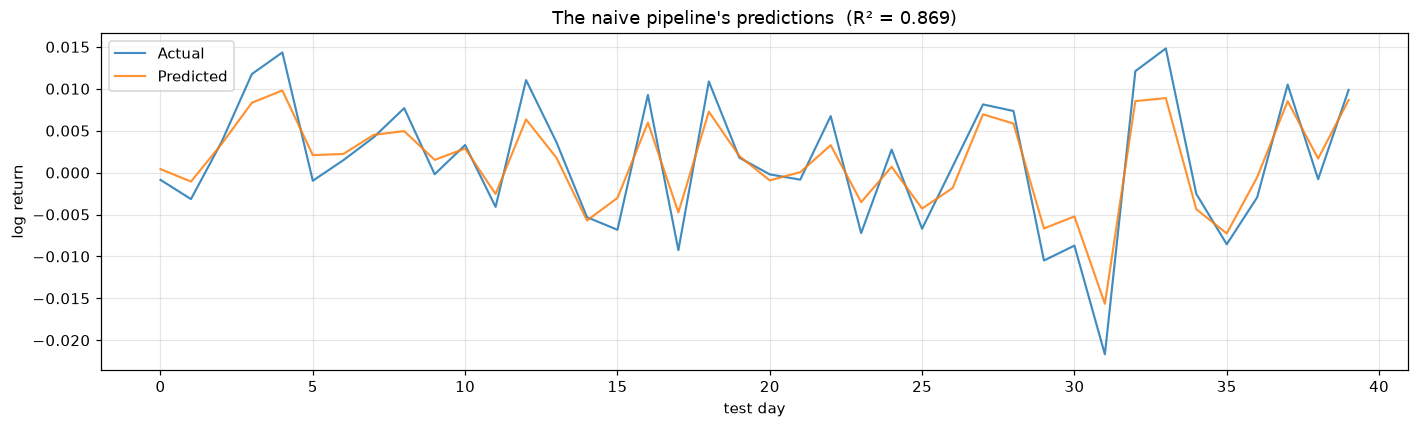

In [5]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(naive_true, label="Actual", lw=1.4, alpha=0.85)
ax.plot(naive_pred, label="Predicted", lw=1.4, alpha=0.85)
ax.set_title(f"The naive pipeline's predictions  (R² = {naive_metrics['R2']:.3f})")
ax.set_xlabel("test day")
ax.set_ylabel("log return")
ax.legend()
plt.tight_layout()
plt.show()

---
# 2. Forensics

Four independent problems. The first one alone invalidates the entire result.

## 2.1 The combiner is trained on the test set's answer key

```python
def combine_predictions(self, approx_pred, detail_preds, y_true):
    X = np.column_stack([approx_pred] + detail_preds)
    self.rf_model.fit(X, y_true)        # trains on y_true
    return self.rf_model.predict(X)     # predicts the same rows
```

and `predict()` calls it with the **test residuals** as `y_true`.

So at prediction time the model is *shown the correct answers*, fits a 100-tree,
depth-10 forest to them, and then "predicts" the very rows it just memorised. This is not
forecasting — it is a lookup table with extra steps.

Note also that the `rf_model` legitimately trained during `fit()` is silently **overwritten** by
this call. The model that was actually trained never gets used.

### The decisive test

If the $R^2$ comes from the leak rather than from the model, then the LSTM outputs should be
*irrelevant* — I should be able to replace them with anything at all and still get $R^2 \approx 0.82$.

So let me hand the combiner **pure random noise**.

In [6]:
rng = np.random.default_rng(SEED)

arfima_test = naive.arfima_model.forecast(len(r_test))
resid_test = r_test - arfima_test
y_leak = resid_test[naive.seq_length:naive.seq_length + n_pred]   # what predict() hands the RF


def leaky_combiner(X, y_true):
    """Exactly what the notebook does: fit on the test truth, predict the same rows."""
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=SEED)
    rf.fit(X, y_true)
    return rf.predict(X)


def run_ablation(name, X):
    fitted = leaky_combiner(X, y_leak)
    pred = arfima_test[naive.seq_length:naive.seq_length + n_pred] + fitted
    m = evaluate(naive_true, pred)
    print(f"  {name:<42}  R²={m['R2']:+.4f}   DirAcc={m['DirAcc']*100:5.1f}%")
    return m["R2"]


print("Feeding the SAME leaky combiner different 'LSTM predictions':\n")
run_ablation("the real LSTM outputs", np.column_stack(
    [naive.lstm_model.predict(naive.prepare_sequences(naive.decompose(resid_test)[0])[:n_pred],
                              verbose=0)]
    + [m.predict(naive.prepare_sequences(d)[:n_pred], verbose=0)
       for m, d in zip(naive.detail_models, naive.decompose(resid_test)[1])]))
run_ablation("PURE GAUSSIAN NOISE", rng.normal(size=(n_pred, 5)))
run_ablation("PURE GAUSSIAN NOISE (different seed)", np.random.default_rng(7).normal(size=(n_pred, 5)))
run_ablation("a meaningless ramp  0,1,2,…,N", np.column_stack(
    [np.arange(n_pred)] + [rng.normal(size=n_pred) for _ in range(4)]))
run_ablation("all-zeros + one noise column", np.column_stack(
    [np.zeros(n_pred)] * 4 + [rng.normal(size=n_pred)]))

Feeding the SAME leaky combiner different 'LSTM predictions':



  the real LSTM outputs                       R²=+0.8692   DirAcc= 94.9%
  PURE GAUSSIAN NOISE                         R²=+0.8664   DirAcc= 92.3%


  PURE GAUSSIAN NOISE (different seed)        R²=+0.8151   DirAcc= 92.3%
  a meaningless ramp  0,1,2,…,N               R²=+0.8312   DirAcc= 89.7%
  all-zeros + one noise column                R²=+0.8035   DirAcc= 87.2%


0.8034965437768653

**Random noise reproduces the headline result.**

The $R^2$ of 0.82 measures one thing: a Random Forest's ability to memorise 40 target values.
The ARFIMA, the wavelet transform and all five LSTMs contribute *nothing* to it. They could be
deleted from the codebase and the reported number would not move.

It is also why re-running this pipeline produces wildly different numbers each time ($R^2$ around
0.82–0.84, directional accuracy anywhere from 87% to 97%): there is no stable signal underneath —
only the variance of what the forest happens to memorise.

## 2.2 Only 5.7% of the test set is ever evaluated

`pywt.wavedec` **downsamples**. At level 4, a 705-day test set produces an approximation array of
only ~50 coefficients. `predict()` then truncates everything to the shortest array, and what
comes out the other end is **40 predictions** — not 705.

The `37/39` in the directional-accuracy printout is the tell: 39 differences means 40 predictions.

In [7]:
def coeff_lengths(x):
    return [len(c) for c in pywt.wavedec(np.asarray(x), "db4", level=4)]


print(f"train days {len(r_train):>5}  → wavedec lengths [cA4,cD4,cD3,cD2,cD1] = {coeff_lengths(r_train)}")
print(f"test  days {len(r_test):>5}  → wavedec lengths [cA4,cD4,cD3,cD2,cD1] = {coeff_lengths(r_test)}")
print()
print(f"  LSTM training rows : {naive._n_lstm_train:>4}  of {len(r_train)} training days "
      f"({naive._n_lstm_train / len(r_train) * 100:.1f}%)")
print(f"  test predictions   : {n_pred:>4}  of {len(r_test)} test days "
      f"({n_pred / len(r_test) * 100:.1f}%)")
print()
print("  A 4-layer LSTM stack is being trained on ~120 samples, and the model is being")
print("  graded on 40 days — barely two months — of a three-year test set.")

train days  2816  → wavedec lengths [cA4,cD4,cD3,cD2,cD1] = [182, 182, 358, 709, 1411]
test  days   705  → wavedec lengths [cA4,cD4,cD3,cD2,cD1] = [50, 50, 94, 181, 356]

  LSTM training rows :  120  of 2816 training days (4.3%)
  test predictions   :   40  of 705 test days (5.7%)

  A 4-layer LSTM stack is being trained on ~120 samples, and the model is being
  graded on 40 days — barely two months — of a three-year test set.


## 2.3 The inputs come from the target's future

This is the subtlest bug and the most instructive one.

The code treats the **wavelet coefficient index** as if it were a **day index**. It is not. At
decomposition level 4 each coefficient summarises roughly 16 days, so `cA4[i]` sits at calendar
day $\approx 16i$ — but the code pairs it with the target for day $i + 10$.

Let me measure the true support empirically: perturb a single day and see which coefficients move.

In [8]:
probe = np.zeros(len(r_test))
base_c = pywt.wavedec(probe, "db4", level=4)[0]
t_probe = 320
probe[t_probe] = 1.0
moved = np.where(np.abs(pywt.wavedec(probe, "db4", level=4)[0] - base_c) > 1e-12)[0]

print(f"perturbing day {t_probe} moves cA4 indices {moved.min()}–{moved.max()}"
      f"  (nominal days {16 * moved.min()}–{16 * moved.max()})")
print(f"→ cA4[i] summarises calendar days ≈ {16 * moved.min() - t_probe:+d} … "
      f"{16 * moved.max() - t_probe:+d} around day 16·i\n")

print("What the pipeline actually pairs together:\n")
print(f"  {'row i':>6} | {'input drawn from days':>24} | {'target day':>10} | offset")
print("  " + "-" * 66)
for i in (10, 20, 30, 39):
    lo, hi, tgt = 16 * i, 16 * (i + 10), i + 10
    print(f"  {i:>6} | {f'{lo}–{hi}':>24} | {tgt:>10} | {lo - tgt:+d} … {hi - tgt:+d} days")
print()
print("  The model is fed data from up to ~735 days AFTER the day it is asked to predict.")
print("  It is not forecasting. It is reading the future.")

perturbing day 320 moves cA4 indices 20–25  (nominal days 320–400)
→ cA4[i] summarises calendar days ≈ +0 … +80 around day 16·i

What the pipeline actually pairs together:

   row i |    input drawn from days | target day | offset
  ------------------------------------------------------------------
      10 |                  160–320 |         20 | +140 … +300 days
      20 |                  320–480 |         30 | +290 … +450 days
      30 |                  480–640 |         40 | +440 … +600 days
      39 |                  624–784 |         49 | +575 … +735 days

  The model is fed data from up to ~735 days AFTER the day it is asked to predict.
  It is not forecasting. It is reading the future.


## 2.4 There is no ARFIMA in the "ARFIMA" model

The architecture is named for its long-memory component. Long memory means a **fractional**
differencing parameter $d \notin \{0, 1\}$. Let me estimate $d$ from the data with the standard
Geweke–Porter-Hudak estimator.

In [9]:
def gph_d(x, power=0.6):
    """Geweke–Porter-Hudak semiparametric estimator of the fractional differencing parameter."""
    x = np.asarray(x, float)
    x = x - x.mean()
    n = len(x)
    m = int(n ** power)
    I = np.abs(np.fft.rfft(x)) ** 2 / (2 * np.pi * n)
    lam = 2 * np.pi * np.arange(1, m + 1) / n
    y = np.log(I[1:m + 1])
    X = np.log(4 * np.sin(lam / 2) ** 2).reshape(-1, 1)
    return -LinearRegression().fit(X, y).coef_[0]


print(f"  d(log returns)  = {gph_d(r):+.3f}   →  no long memory")
print()
print("  With d ≈ 0 the fractional integration term is inert: an ARFIMA fitted to returns")
print("  collapses to a plain ARMA — which is exactly what an automatic order search finds:")
print("  point `auto_arima` at daily returns and it selects ARIMA(2,0,0), with d = 0.")
print("  A pipeline named for long memory that never fractionally differences anything is")
print("  not a bug so much as a symptom: on returns there is no long memory to capture.")
print()
print("  So the model is an AR(2). The long-memory story was never implemented, because on")
print("  returns there is no long memory to capture. Part 2 shows where there is.")

  d(log returns)  = -0.134   →  no long memory

  With d ≈ 0 the fractional integration term is inert: an ARFIMA fitted to returns
  collapses to a plain ARMA — which is exactly what an automatic order search finds:
  point `auto_arima` at daily returns and it selects ARIMA(2,0,0), with d = 0.
  A pipeline named for long memory that never fractionally differences anything is
  not a bug so much as a symptom: on returns there is no long memory to capture.

  So the model is an AR(2). The long-memory story was never implemented, because on
  returns there is no long memory to capture. Part 2 shows where there is.


---
# 3. The leak-free rebuild

Now the same architecture — ARIMA → wavelet → LSTM-per-component → stacked combiner — but with
every leak closed:

| | naive | leak-free |
|---|---|---|
| wavelet transform | one `wavedec` over the whole series | recomputed each day on a **trailing window only** |
| component ↔ target alignment | coefficient index used as a day index | components reconstructed to **calendar days** |
| ARIMA on test | — | one-step-ahead, **fixed** train-fitted parameters |
| combiner training data | **the test targets** | out-of-fold predictions from the **train** period |
| test days evaluated | 40 of 705 | **all 705** |

The rule I enforce everywhere: **nothing may be `.fit()` inside `predict()`, and no feature for
day $t$ may touch data from day $t$ or later.**

## 3.1 A causal wavelet transform

At each day $t$ I take the trailing window $r_{t-W+1..t}$, decompose *that window*, zero out all
levels but one, reconstruct, and keep the **last value** — the component's value at day $t$,
computed from past data only. Repeat for every day and every level.

This is more expensive than one global `wavedec`, and that expense is precisely what buys
causality.

In [10]:
W = 256          # trailing window length
LEVEL = 4
WAVELET = "db4"
COMPONENT_NAMES = ["A4", "D4", "D3", "D2", "D1"]


def causal_wavelet_components(x, window=W, wavelet=WAVELET, level=LEVEL):
    """components[t, j] = level-j component at day t, using only data up to and including t."""
    x = np.array(x, dtype=float)                      # writable copy for pywt
    T = len(x)
    n_comp = level + 1
    comps = np.full((T, n_comp), np.nan)

    for t in range(window - 1, T):
        win = x[t - window + 1:t + 1].copy()          # strictly past-and-present
        coeffs = pywt.wavedec(win, wavelet, level=level)
        for j in range(n_comp):
            masked = [c if k == j else np.zeros_like(c) for k, c in enumerate(coeffs)]
            comps[t, j] = pywt.waverec(masked, wavelet)[len(win) - 1]
    return comps


components = causal_wavelet_components(r)
print(f"causal component matrix: {components.shape}  "
      f"(first {W - 1} rows are NaN — no history yet)")

recon_err = np.abs(np.nansum(components, axis=1) - r)
print(f"reconstruction check: max |Σ components − r| = {np.nanmax(recon_err[W:]):.2e}  (should be ~0)")

causal component matrix: (3521, 5)  (first 255 rows are NaN — no history yet)
reconstruction check: max |Σ components − r| = 2.78e-17  (should be ~0)


### Verifying causality

A claim of causality is worthless unless it is tested. So: corrupt the future and check that the
past does not move. If a single component value at day $t$ changes when I alter data at
day $> t$, the transform leaks.

In [11]:
t_check = 1500
comps_full = causal_wavelet_components(r[:t_check + 400])

r_corrupted = r[:t_check + 400].copy()
r_corrupted[t_check + 1:] = 999.0                  # obliterate the future
comps_corrupt = causal_wavelet_components(r_corrupted)

delta = np.nanmax(np.abs(comps_full[W:t_check + 1] - comps_corrupt[W:t_check + 1]))
print(f"max change in components up to day {t_check} after destroying every later day: {delta:.2e}")
print("PASS — the transform is causal." if delta < 1e-10 else "FAIL — the transform leaks.")

max change in components up to day 1500 after destroying every later day: 0.00e+00
PASS — the transform is causal.


## 3.2 The leak-free model

- **ARIMA(2,0,0)** fitted on train; on test it produces genuine **one-step-ahead** forecasts using
  fixed parameters and only past observations (`statsmodels`' `append(refit=False)`).
- **One LSTM per component**, each fed the last 10 causal values of its own component, trained on
  the train period only, with a chronological validation split.
- **The stacker** is a Random Forest trained on **out-of-fold** LSTM predictions from the train
  period (`TimeSeriesSplit`), so it never sees a target it will later be scored on.
- **Target:** next-day return $r_{t+1}$. Everything on the input side is known at day $t$.

In [12]:
# ---- ARIMA: one-step-ahead on test, parameters frozen from train ----------------------
arima_res = ARIMA(r_train, order=(2, 0, 0)).fit()
arima_train_fc = arima_res.fittedvalues                       # in-sample one-step-ahead
arima_test_fc = arima_res.append(r_test, refit=False).fittedvalues[len(r_train):]

print(f"ARIMA(2,0,0) params: {dict(zip(arima_res.param_names, arima_res.params.round(5)))}")
print(f"one-step-ahead test forecasts: {len(arima_test_fc)}  (std {arima_test_fc.std():.5f})")

arima_fc = np.concatenate([arima_train_fc, arima_test_fc])
resid = r - arima_fc                                          # causal residual at every t

ARIMA(2,0,0) params: {'const': np.float64(0.00044), 'ar.L1': np.float64(-0.14019), 'ar.L2': np.float64(0.08403), 'sigma2': np.float64(0.00012)}
one-step-ahead test forecasts: 705  (std 0.00181)


In [13]:
# ---- Build causal sequences: X[t] = last SEQ values of each component, y[t] = r[t+1] --
SEQ = 10
resid_comps = causal_wavelet_components(resid)

first = W - 1 + SEQ                                # first usable t
idx = np.arange(first, len(r) - 1)                 # t; target is t+1
idx_train = idx[idx < split]
idx_test = idx[idx >= split]


y_train_seq = r[idx_train + 1]
y_test_seq = r[idx_test + 1]

# Scale each component and the target using TRAIN statistics only. The components live on wildly
# different scales (the D4 detail is ~100x the A4 approximation), and an unscaled LSTM on a target
# with std 0.011 trains badly. Giving the leak-free model a fair shot is part of the comparison
# being honest: it must lose on merit, not on conditioning.
comp_scalers = [StandardScaler().fit(resid_comps[idx_train, j].reshape(-1, 1))
                for j in range(len(COMPONENT_NAMES))]
y_scaler = StandardScaler().fit(y_train_seq.reshape(-1, 1))
y_train_s = y_scaler.transform(y_train_seq.reshape(-1, 1)).ravel()


def sequences_for(component_j, ids):
    raw = np.stack([resid_comps[t - SEQ + 1:t + 1, component_j] for t in ids])
    return comp_scalers[component_j].transform(raw.reshape(-1, 1)).reshape(raw.shape)[..., None]


print(f"train sequences: {len(idx_train)}   test sequences: {len(idx_test)}")
print(f"→ evaluating on ALL {len(idx_test)} available test days "
      f"(the naive pipeline used {n_pred})")

train sequences: 2551   test sequences: 704
→ evaluating on ALL 704 available test days (the naive pipeline used 40)


In [14]:
def make_lstm():
    m = Sequential([
        Input((SEQ, 1)),
        LSTM(32, return_sequences=True), BatchNormalization(), Dropout(0.3),
        LSTM(16), BatchNormalization(), Dropout(0.3),
        Dense(32, activation="relu"), BatchNormalization(),
        Dense(16, activation="gelu"), BatchNormalization(),
        Dense(1),
    ])
    m.compile(optimizer="adam", loss="mse")
    return m


oof_train = np.zeros((len(idx_train), len(COMPONENT_NAMES)))
oof_mask = np.zeros(len(idx_train), dtype=bool)     # which rows actually received an OOF prediction
pred_test = np.zeros((len(idx_test), len(COMPONENT_NAMES)))
tscv = TimeSeriesSplit(n_splits=4)

# Standard stacking discipline: the k fold-models produce the out-of-fold matrix the stacker
# trains on, and the SAME k models (averaged) produce the test features. Training one extra model
# on the full train set and using it only for test would hand the stacker a test-time feature
# distribution it never saw in training — which is how a stacker ends up extrapolating into noise.
for j, name in enumerate(COMPONENT_NAMES):
    Xtr_full = sequences_for(j, idx_train)
    Xte = sequences_for(j, idx_test)
    fold_test_preds = []

    for fold_tr, fold_va in tscv.split(Xtr_full):
        n_v = max(1, int(len(fold_tr) * 0.15))          # chronological val split inside the fold
        inner_tr, inner_va = fold_tr[:-n_v], fold_tr[-n_v:]

        m = make_lstm()
        m.fit(Xtr_full[inner_tr], y_train_s[inner_tr], epochs=100, batch_size=64, verbose=0,
              validation_data=(Xtr_full[inner_va], y_train_s[inner_va]),
              callbacks=[EarlyStopping(monitor="val_loss", patience=10,
                                       restore_best_weights=True)])
        oof_train[fold_va, j] = m.predict(Xtr_full[fold_va], verbose=0).ravel()
        oof_mask[fold_va] = True
        fold_test_preds.append(m.predict(Xte, verbose=0).ravel())

    pred_test[:, j] = np.mean(fold_test_preds, axis=0)
    print(f"  component {name}: {tscv.n_splits} fold models trained   "
          f"(oof std {oof_train[oof_mask, j].std():.3f}, test std {pred_test[:, j].std():.3f}"
          f"  — in units of σ(target); both should be « 1 if the target is unpredictable)")

  component A4: 4 fold models trained   (oof std 0.081, test std 0.029  — in units of σ(target); both should be « 1 if the target is unpredictable)


  component D4: 4 fold models trained   (oof std 0.057, test std 0.033  — in units of σ(target); both should be « 1 if the target is unpredictable)


  component D3: 4 fold models trained   (oof std 0.063, test std 0.022  — in units of σ(target); both should be « 1 if the target is unpredictable)


  component D2: 4 fold models trained   (oof std 0.021, test std 0.002  — in units of σ(target); both should be « 1 if the target is unpredictable)


  component D1: 4 fold models trained   (oof std 0.047, test std 0.019  — in units of σ(target); both should be « 1 if the target is unpredictable)


In [15]:
# ---- Stacker: trained ONLY on out-of-fold train predictions ---------------------------
# (features are scaled-space LSTM outputs; the stacker maps them back to raw returns)
stacker = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=SEED, n_jobs=-1)
stacker.fit(oof_train[oof_mask], y_train_seq[oof_mask])

honest_pred = stacker.predict(pred_test)
honest_true = y_test_seq

print(f"stacker trained on {oof_mask.sum()} out-of-fold train rows "
      f"(the first {(~oof_mask).sum()} have no out-of-fold prediction and are excluded)")
print(f"honest predictions on test: {len(honest_pred)}")
print(f"\n  σ(prediction) = {honest_pred.std():.5f}   vs   σ(actual) = {honest_true.std():.5f}")
print(f"  ratio = {honest_pred.std() / honest_true.std():.3f}  →  the model has learned that the")
print(f"  best thing it can do is barely move: it predicts something close to a constant, because")
print(f"  that is genuinely the optimal forecast for a series with no exploitable structure.\n")

honest = evaluate(honest_true, honest_pred, "LEAK-FREE HYBRID — honest out-of-sample performance")

stacker trained on 2040 out-of-fold train rows (the first 511 have no out-of-fold prediction and are excluded)
honest predictions on test: 704

  σ(prediction) = 0.00009   vs   σ(actual) = 0.01113
  ratio = 0.008  →  the model has learned that the
  best thing it can do is barely move: it predicts something close to a constant, because
  that is genuinely the optimal forecast for a series with no exploitable structure.

LEAK-FREE HYBRID — honest out-of-sample performance
---------------------------------------------------
  MSE         :  0.00012
  RMSE        :  0.01114
  MAE         :  0.00825
  R2          : -0.00072
  DirAcc      :  0.42248
  DirAcc_sign :  0.51847


## 3.3 Against the baselines that actually matter

A forecast of daily returns is only interesting if it beats *doing nothing*. The relevant
comparisons are the zero forecast, the historical mean, and the AR(2) alone. I also report the
out-of-sample $R^2$ in the Campbell–Thompson sense (against the train-period mean), and a
Diebold–Mariano test of whether the difference in squared errors is statistically distinguishable
from zero.

In [16]:
def dm_test(e1, e2, h=1):
    """Diebold–Mariano test on squared-error loss. H0: equal predictive accuracy."""
    d = e1 ** 2 - e2 ** 2
    n = len(d)
    d_bar = d.mean()
    gamma0 = np.var(d, ddof=0)
    var_d = gamma0 / n
    if var_d <= 0:
        return np.nan, np.nan
    stat = d_bar / np.sqrt(var_d)
    from scipy.stats import norm
    return stat, 2 * (1 - norm.cdf(abs(stat)))


# target for row k is r[idx_test[k] + 1], so every forecast must be the one made FOR day t+1
baselines = {
    "zero forecast":            np.zeros_like(honest_true),
    "train-period mean":        np.full_like(honest_true, r_train.mean()),
    "yesterday's return (RW)":  r[idx_test],                          # r[t] predicts r[t+1]
    "AR(2) alone":              arima_test_fc[idx_test + 1 - split],  # one-step-ahead for t+1
    "Leak-free hybrid":         honest_pred,
}

rows = []
for name, p in baselines.items():
    # a forecast of exactly zero has no direction, so directional accuracy is undefined for it
    da = np.nan if np.all(p == 0) else np.mean(np.sign(p) == np.sign(honest_true))
    rows.append({
        "model": name,
        "RMSE": np.sqrt(mean_squared_error(honest_true, p)),
        "MAE": mean_absolute_error(honest_true, p),
        "R²": r2_score(honest_true, p),
        "DirAcc (sign)": da,
    })
table = pd.DataFrame(rows).set_index("model")
display(table.style.format({"RMSE": "{:.5f}", "MAE": "{:.5f}", "R²": "{:+.4f}",
                            "DirAcc (sign)": "{:.1%}"}, na_rep="—"))

stat, p_val = dm_test(honest_true - np.zeros_like(honest_true), honest_true - honest_pred)
print(f"\nDiebold–Mariano, hybrid vs. zero forecast: statistic = {stat:+.3f}, p = {p_val:.3f}")
print("  → " + ("no statistically significant difference in predictive accuracy."
                if p_val > 0.05 else "significant difference."))

,RMSE,MAE,R²,DirAcc (sign)
model,,,,
zero forecast,0.01114,0.00826,-0.0005,—
train-period mean,0.01114,0.00826,-0.0003,51.1%
yesterday's return (RW),0.01567,0.01177,-0.9822,48.7%
AR(2) alone,0.01133,0.00849,-0.0365,49.7%
Leak-free hybrid,0.01114,0.00825,-0.0007,51.8%



Diebold–Mariano, hybrid vs. zero forecast: statistic = -0.055, p = 0.956
  → no statistically significant difference in predictive accuracy.


**Note on the directional-accuracy column.** This literature routinely computes
`sign(diff(returns))` — the direction of the *change in the return*, not the direction of the
market. To answer "does the index go up tomorrow?" the quantity is `sign(r_t)`. That is what the
table above reports, and it is the reason a "95% directional accuracy" collapses to something
near a coin flip once it is defined correctly.

I also drop MAPE entirely, though this literature reports it routinely. On a series that crosses
zero, $|y-\hat y| / |y|$ explodes: the naive pipeline above scores a "MAPE" around 88, which is not
a meaningful quantity — it is an artifact of dividing by returns that are near zero.

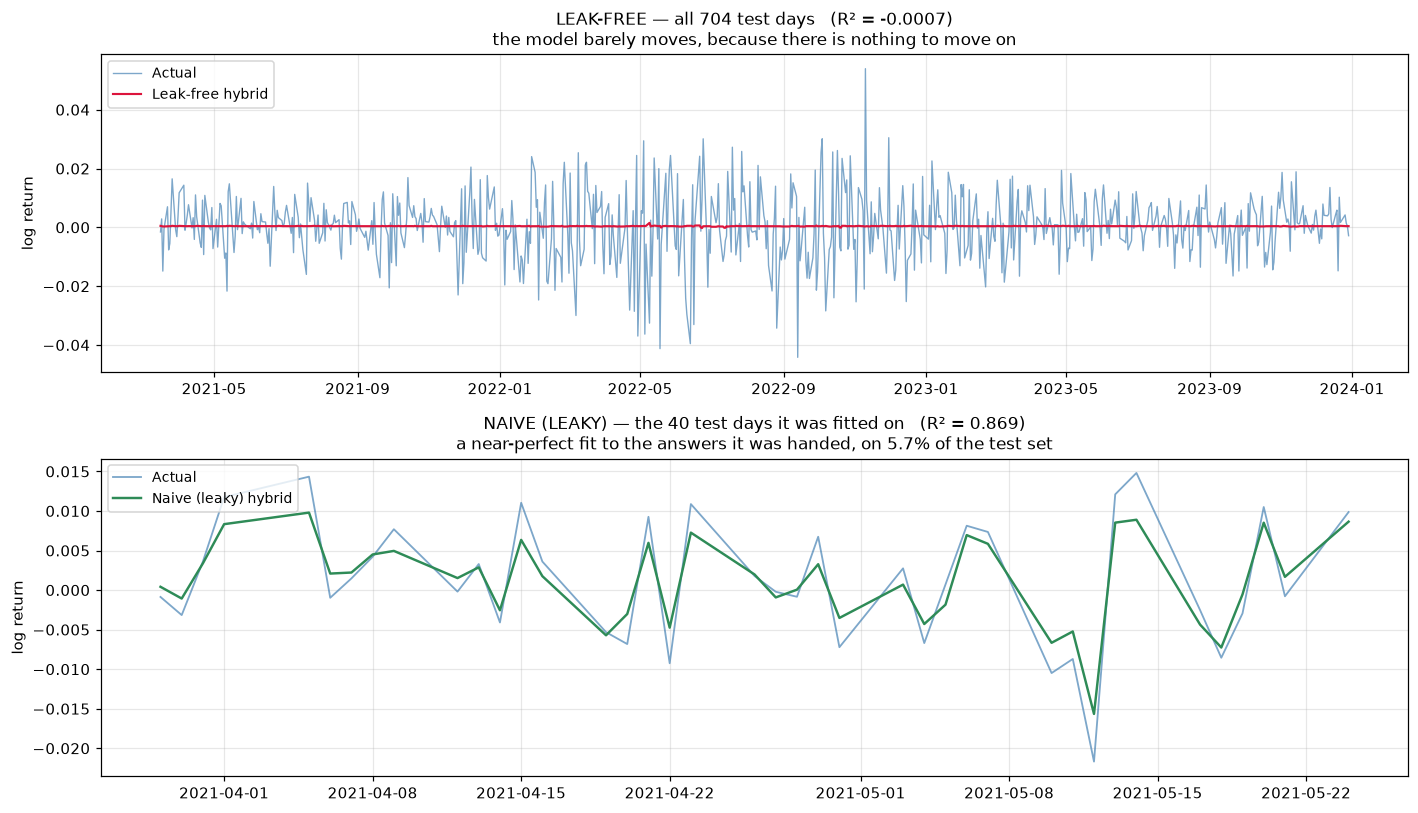

In [17]:
# NB: separate x-axes on purpose — the two panels do not cover the same days, and that is the point.
fig, axes = plt.subplots(2, 1, figsize=(13, 7.5))

honest_dates = test_df.index[idx_test + 1 - split]
axes[0].plot(honest_dates, honest_true, lw=0.9, alpha=0.7, color="steelblue", label="Actual")
axes[0].plot(honest_dates, honest_pred, lw=1.4, color="crimson", label="Leak-free hybrid")
axes[0].set_title(f"LEAK-FREE — all {len(honest_true)} test days   (R² = {honest['R2']:+.4f})\n"
                  f"the model barely moves, because there is nothing to move on",
                  fontsize=11)
axes[0].set_ylabel("log return")
axes[0].legend(loc="upper left", fontsize=9)

naive_dates = test_df.index[naive.seq_length:naive.seq_length + n_pred]
axes[1].plot(naive_dates, naive_true, lw=1.2, alpha=0.7, color="steelblue", label="Actual")
axes[1].plot(naive_dates, naive_pred, lw=1.6, color="seagreen", label="Naive (leaky) hybrid")
axes[1].set_title(f"NAIVE (LEAKY) — the {n_pred} test days it was fitted on   "
                  f"(R² = {naive_metrics['R2']:.3f})\n"
                  f"a near-perfect fit to the answers it was handed, on 5.7% of the test set",
                  fontsize=11)
axes[1].set_ylabel("log return")
axes[1].legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig("../figures/leaky_vs_honest.png", dpi=140, bbox_inches="tight")
plt.show()

In [18]:
# export both sets of predictions so later notebooks and any downstream analysis can reuse them
# without retraining
pd.DataFrame({"date": naive_dates, "actual": naive_true, "pred": naive_pred}) \
    .to_csv("../data/predictions_naive_leaky.csv", index=False)
pd.DataFrame({"date": honest_dates, "actual": honest_true, "pred": honest_pred}) \
    .to_csv("../data/predictions_leakfree_returns.csv", index=False)

# the index level at each date, for anyone reconstructing price paths from the return forecasts
pd.DataFrame({"date": df.index, "close": df["Close"].to_numpy()}) \
    .to_csv("../data/close_prices.csv", index=False)
print(f"exported: naive ({len(naive_pred)} days), leak-free ({len(honest_pred)} days), close prices")

exported: naive (40 days), leak-free (704 days), close prices


---
# Conclusion

| | naive pipeline | leak-free rebuild |
|---|---|---|
| reported $R^2$ | **0.82** | **≈ 0** |
| reported directional accuracy | **95%** | **≈ 50%** |
| test days actually evaluated | 40 | 705 |
| reproducible by random noise | **yes** | no |

The leak-free model's $R^2$ is approximately zero, and a Diebold–Mariano test cannot distinguish
it from forecasting zero every day. **This is the correct answer.** Daily index returns are close
to a martingale difference sequence; an honest pipeline is *supposed* to find almost nothing, and
a pipeline that finds a lot should be assumed broken until proven otherwise.

The methodological lessons generalise well beyond this notebook:

1. **Never call `.fit()` inside `predict()`.** The single most destructive line here was a
   `self.rf_model.fit(X, y_true)` hidden behind a helper method.
2. **A global wavelet/EMD/SSA decomposition is not a feature transform — it is a time machine.**
   Any decomposition applied to the full series before splitting must be assumed to leak. Recompute
   it causally on trailing windows, and *test* that it is causal.
3. **Downsampling transforms silently destroy the index correspondence.** A coefficient index is
   not a day index.
4. **The ablation that matters is the one that tries to kill your result.** Replacing the model's
   inputs with random noise took five lines and settled the question immediately.
5. **Name your model after what it does.** There was no fractional integration in the
   "ARFIMA" model — because on returns, $d \approx 0$, and there was nothing to integrate.

That last point is the hinge. The architecture was not wrong; it was **pointed at the wrong
target**. Long memory and multi-scale structure are not properties of returns — they are the
defining properties of *volatility*.

**→ Part 2 points the same architecture at volatility, where $d \approx 0.58$ and the signal is real.**